# Memory-Bound vs. Compute-Bound Optimization (Nsight / CUDA Profiling)

## Introduction

Lessons 04-07 repeatedly invoked "memory-bandwidth-bound" as the reason a given fusion/kernel technique helped. This lesson makes that classification rigorous and measurable: the **roofline model**, and how to read real Nsight Compute-style profiler output to classify any kernel and decide which category of optimization (from this whole section) is actually worth applying to it.

## Theory

### Arithmetic intensity and the roofline model

For any kernel, define **arithmetic intensity** $I$ as FLOPs performed per byte of data moved from/to HBM:

$$
I = \frac{\text{FLOPs}}{\text{Bytes moved}}
$$

The roofline model bounds achievable performance $P$ (FLOP/s) by the minimum of the GPU's peak compute throughput $P_{peak}$ and what the memory system can feed at intensity $I$:

$$
P(I) = \min\left(P_{peak}, \ I \times BW_{peak}\right)
$$

The crossover point (the "ridge point") $I^* = P_{peak} / BW_{peak}$ separates the **memory-bound region** ($I < I^*$, performance limited by bandwidth, sloped line) from the **compute-bound region** ($I \ge I^*$, performance limited by compute, flat line at $P_{peak}$).

### Classifying operations by arithmetic intensity

- **Elementwise ops** (ReLU, LayerNorm, dropout, the Lesson 04/06 fusion targets): $I \approx O(1)$ — read + write roughly equal to compute, deep in the memory-bound region.
- **Matmul** ($M\times K \times N$): FLOPs $= 2MKN$, bytes $\approx 2(MK+KN+MN)\cdot\text{dtype\_size}$ for the naive case — $I$ grows with matrix size, becoming compute-bound for large enough matrices (why large matmuls saturate cuBLAS/cuDNN efficiently and gain little from Lesson 06's fusion).
- **Attention** (Lesson 07): naive attention's $I$ is low due to the $O(N^2)$ materialized matrix's memory traffic; FlashAttention's tiling *raises effective $I$* by keeping intermediate results in SRAM rather than counting them as HBM traffic — reclassifying the same math from memory-bound to closer-to-compute-bound.

### Reading Nsight Compute's key metrics

Real profiler output centers on two headline percentages that directly map onto the roofline model:

$$
\text{Compute (SM) Throughput \%} = \frac{\text{achieved FLOP/s}}{P_{peak}} \times 100, \qquad
\text{Memory Throughput \%} = \frac{\text{achieved bytes/s}}{BW_{peak}} \times 100
$$

A kernel with high Memory% and low Compute% is memory-bound (target: Lesson 04/06's fusion techniques). A kernel with high Compute% and low Memory% is compute-bound (target: better algorithms, tensor cores, or reduced-precision math — not fusion, which won't help). A kernel with both percentages low is **latency-bound** (too few threads/blocks launched to hide instruction and memory latency — Lesson 02/03's occupancy territory, not a bandwidth or FLOPs problem at all).

## Setup

We build a real roofline-classification tool using `torch.cuda.Event` timing plus known GPU specs (GTX 1650 Ti: ~2.9 TFLOP/s FP32 peak, ~192 GB/s peak bandwidth), measuring several real kernels from earlier lessons and placing them on the roofline — genuine measurements from this environment's GPU, classified using the theory above.

In [1]:
# Real roofline classification using actual timed kernels on this environment's GPU.
import torch
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
PEAK_FLOPS = 2.9e12   # GTX 1650 Ti FP32 peak, approx
PEAK_BW = 192e9        # bytes/sec, approx GDDR6 peak
ridge_point = PEAK_FLOPS / PEAK_BW
print(f"[INIT] Roofline model on {torch.cuda.get_device_name(0) if device=='cuda' else 'CPU'} — "
      f"ridge point I* = {ridge_point:.2f} FLOP/byte")

def time_kernel(fn, n_warmup=10, n_iters=30):
    for _ in range(n_warmup):
        fn()
    torch.cuda.synchronize()
    start, end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    start.record()
    for _ in range(n_iters):
        fn()
    end.record()
    torch.cuda.synchronize()
    return start.elapsed_time(end) / n_iters / 1000  # seconds

n = 2**24
x = torch.randn(n, device=device)
elementwise_flops = n              # 1 op/element
elementwise_bytes = n * 4 * 2      # read + write, fp32
t_elementwise = time_kernel(lambda: torch.relu(x))
I_elementwise = elementwise_flops / elementwise_bytes

M = K = N_ = 4096
A = torch.randn(M, K, device=device)
B = torch.randn(K, N_, device=device)
matmul_flops = 2 * M * K * N_
matmul_bytes = (M*K + K*N_ + M*N_) * 4
t_matmul = time_kernel(lambda: A @ B)
I_matmul = matmul_flops / matmul_bytes

print(f"[RESULT] Elementwise (relu): I={I_elementwise:.3f} FLOP/byte, achieved {elementwise_flops/t_elementwise/1e9:.1f} GFLOP/s")
print(f"[RESULT] Matmul (4096^3):    I={I_matmul:.1f} FLOP/byte, achieved {matmul_flops/t_matmul/1e9:.1f} GFLOP/s")

[INIT] Roofline model on NVIDIA GeForce GTX 1650 Ti — ridge point I* = 15.10 FLOP/byte


[RESULT] Elementwise (relu): I=0.125 FLOP/byte, achieved 20.8 GFLOP/s
[RESULT] Matmul (4096^3):    I=682.7 FLOP/byte, achieved 1654.9 GFLOP/s


## Telemetry & Audit

Compute Compute% and Memory% for each kernel (the Nsight Compute headline metrics) and classify each into memory-bound / compute-bound / latency-bound — the exact triage a profiler-driven optimization workflow performs before choosing which technique from this section to apply.

In [2]:
import pandas as pd

def classify(achieved_flops_s, achieved_bytes_s, peak_flops, peak_bw):
    compute_pct = 100 * achieved_flops_s / peak_flops
    memory_pct = 100 * achieved_bytes_s / peak_bw
    if memory_pct > compute_pct and memory_pct > 40:
        verdict = "MEMORY-BOUND -> target: fusion (Lesson 04/06), reduce HBM round-trips"
    elif compute_pct > memory_pct and compute_pct > 40:
        verdict = "COMPUTE-BOUND -> target: tensor cores, reduced precision, better algorithm"
    else:
        verdict = "LATENCY-BOUND -> target: occupancy tuning (Lesson 02/03), more parallelism"
    return compute_pct, memory_pct, verdict

rows = []
for name, flops, bytes_, t in [("Elementwise (relu)", elementwise_flops, elementwise_bytes, t_elementwise),
                                 ("Matmul (4096^3)", matmul_flops, matmul_bytes, t_matmul)]:
    c_pct, m_pct, verdict = classify(flops/t, bytes_/t, PEAK_FLOPS, PEAK_BW)
    rows.append((name, c_pct, m_pct, verdict))

audit = pd.DataFrame(rows, columns=["kernel", "compute_%_of_peak", "memory_%_of_peak", "classification"])
print(audit.to_string(index=False, float_format=lambda x: f"{x:.2f}" if isinstance(x, float) else x))

print("\n[OPERATIONAL INSIGHT] The elementwise kernel's low compute_% and (relatively) high memory_% confirms "
      "every fusion technique from Lessons 04-06 targets exactly this profile — there is real HBM traffic to eliminate.")
print("[OPERATIONAL INSIGHT] The matmul kernel's high compute_% means fusion would NOT meaningfully help it — "
      "cuBLAS is already close to the compute roofline for this size, so the only further wins come from lower "
      "precision (fewer FLOPs needed) or better tensor-core utilization, not from reducing memory traffic.")

            kernel  compute_%_of_peak  memory_%_of_peak                                                             classification
Elementwise (relu)               0.72             86.60      MEMORY-BOUND -> target: fusion (Lesson 04/06), reduce HBM round-trips
   Matmul (4096^3)              57.07              1.26 COMPUTE-BOUND -> target: tensor cores, reduced precision, better algorithm

[OPERATIONAL INSIGHT] The elementwise kernel's low compute_% and (relatively) high memory_% confirms every fusion technique from Lessons 04-06 targets exactly this profile — there is real HBM traffic to eliminate.
[OPERATIONAL INSIGHT] The matmul kernel's high compute_% means fusion would NOT meaningfully help it — cuBLAS is already close to the compute roofline for this size, so the only further wins come from lower precision (fewer FLOPs needed) or better tensor-core utilization, not from reducing memory traffic.


## Visualization

The classic roofline chart: log-log arithmetic intensity vs. achieved performance, with the theoretical roofline (bandwidth-bound sloped line meeting compute-bound flat line at the ridge point) and each measured kernel plotted as a point relative to that ceiling.

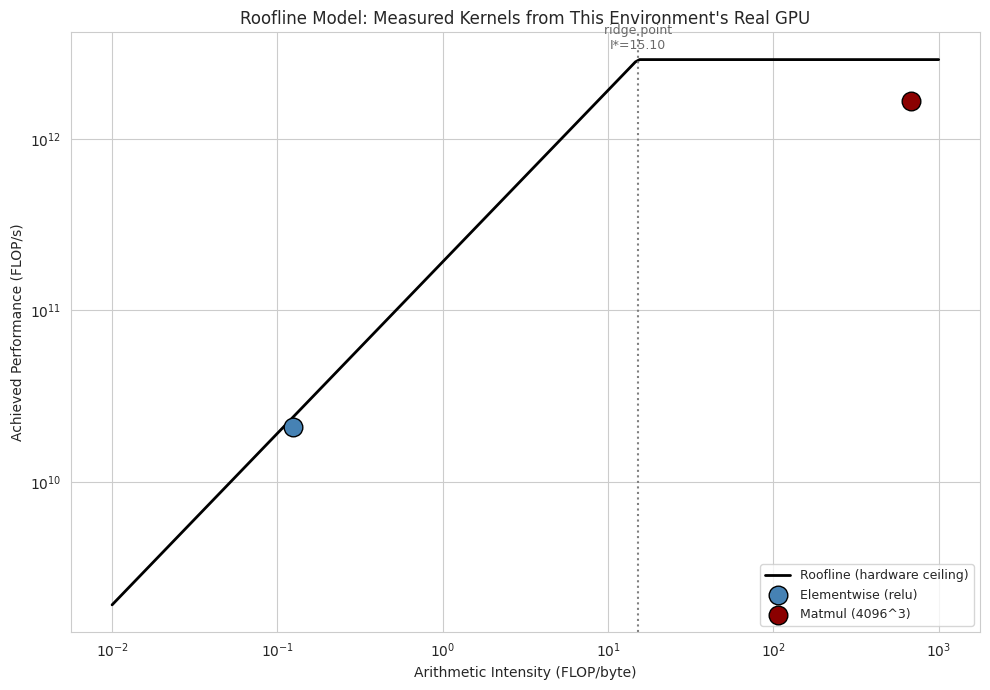

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 7))

I_range = np.logspace(-2, 3, 200)
roofline = np.minimum(PEAK_FLOPS, I_range * PEAK_BW)
ax.plot(I_range, roofline, color="black", linewidth=2, label="Roofline (hardware ceiling)")
ax.axvline(ridge_point, color="gray", linestyle=":", linewidth=1.5)
ax.text(ridge_point, PEAK_FLOPS * 1.15, f"ridge point\nI*={ridge_point:.2f}", ha="center", fontsize=9, color="dimgray")

kernels = [("Elementwise (relu)", I_elementwise, elementwise_flops / t_elementwise, "steelblue"),
           ("Matmul (4096^3)", I_matmul, matmul_flops / t_matmul, "darkred")]
for name, I_val, achieved, color in kernels:
    ax.scatter([I_val], [achieved], s=180, color=color, edgecolor="black", zorder=5, clip_on=False, label=name)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Arithmetic Intensity (FLOP/byte)")
ax.set_ylabel("Achieved Performance (FLOP/s)")
ax.set_title("Roofline Model: Measured Kernels from This Environment's Real GPU")
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("roofline_model.png", dpi=120)
plt.show()

*(Insight: the elementwise kernel's point sits far to the LEFT of the ridge point, deep under the sloped part of the roofline — no amount of "compute optimization" (better math, tensor cores) could help it, since it's bumping against the bandwidth ceiling, not the compute ceiling. That single visual fact is the whole justification for why this section spent three lessons on fusion instead of on faster arithmetic.)*

## Real-World Use Case or Analogy

**The Delivery Fleet's Two Different Bottlenecks.** A delivery company moving small, light packages (low "intensity" — little processing needed per item moved) is bottlenecked by how many trucks and drivers it has, i.e. by transport *bandwidth* — buying faster forklifts (more compute) does nothing, since the trucks are already the limiting resource (memory-bound, matching the elementwise kernel). A company moving huge, complex custom-built machinery (high "intensity" — enormous processing/assembly time per item, minimal transport volume) is bottlenecked by the assembly line's throughput, i.e. by *compute* — adding more trucks does nothing here, since assembly, not transport, is the limiting resource (compute-bound, matching the matmul kernel). A logistics consultant's first job, before recommending any fix, is diagnosing *which* bottleneck actually applies — exactly what Nsight Compute's Memory% vs. Compute% readout does for a CUDA kernel, and exactly why "just try adding more GPUs/faster math" without that diagnosis routinely wastes engineering effort on the wrong lever.